# Filtering vs Ranking Policy: Logit Scale Analysis

SynPlanner uses two policy networks to guide retrosynthetic search:

- **Filtering network**: trained with binary cross-entropy (multi-label). Predicts whether each rule is *applicable* to the molecule. Output: `sigmoid(logits)` per rule.
- **Ranking network**: trained with cross-entropy (multi-class). Predicts which single rule was used in training data. Output: `softmax(logits)` over all rules.

In the **additive combination mode**, the combined policy merges both signals as:

$$\text{combined} = \text{filtering\_logits} + w \cdot \text{ranking\_logits}$$
$$P(\text{rule}_i) = \text{softmax}(\text{combined} / T)$$

where $w$ = `ranking_weight` (default 1.0) and $T$ = `temperature` (default 1.0).

This notebook investigates whether the two logit distributions have compatible scales, and how much each network actually contributes to the final rule ranking.

In [10]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from synplan.mcts.expansion import PolicyNetworkFunction
from synplan.utils.loading import download_preset
from synplan.utils.loading import load_reaction_rules
from synplan.utils.config import PolicyNetworkConfig
from synplan.chem.utils import mol_from_smiles
from synplan.chem.precursor import Precursor

# Publication style
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

COLORS = {"filtering": "#2196F3", "ranking": "#F44336", "combined": "#9C27B0"}

In [8]:
# Download pre-trained policy networks
paths = download_preset("synplanner-article", save_to=Path("synplan_data"))

Couldn't access the Hub to check for update but local file already exists. Defaulting to existing file. (error: [Errno -3] Temporary failure in name resolution)


In [12]:
# Load both policy networks
filtering_fn = PolicyNetworkFunction(
    PolicyNetworkConfig(
        weights_path=paths["filtering_policy"],
        policy_type="filtering",
        top_rules=50,
    )
)
ranking_fn = PolicyNetworkFunction(
    PolicyNetworkConfig(
        weights_path=paths["ranking_policy"],
        policy_type="ranking",
        top_rules=50,
    )
)

Lightning automatically upgraded your loaded checkpoint from v1.9.5 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint synplan_data/policy/supervised_gcn/v1/v1/filtering_policy.ckpt`
Lightning automatically upgraded your loaded checkpoint from v1.9.5 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint synplan_data/policy/supervised_gcn/v1/v1/ranking_policy.ckpt`


In [13]:
# Load SAS benchmark molecules
bins = ["1.5_2.5", "2.5_3.5", "3.5_4.5", "4.5_5.5", "5.5_6.5", "6.5_7.5", "7.5_8.5"]
data_dir = Path("../scripts/benchmark/sascore")

molecules = []  # list of (smiles, bin_label, Precursor)
for b in bins:
    smi_file = data_dir / f"targets_with_sascore_{b}.smi"
    for smi in smi_file.read_text().splitlines():
        smi = smi.strip()
        if not smi:
            continue
        mol = mol_from_smiles(smi, standardize=True)
        if mol is not None:
            molecules.append((smi, b, Precursor(mol)))

print(f"Loaded {len(molecules)} molecules across {len(bins)} bins")


Loaded 700 molecules across 7 bins


In [18]:
# Extract logits for all molecules
records = []  # per-molecule summary stats

for i, (smi, b, prec) in enumerate(molecules):
    fl = filtering_fn.get_logits(prec)
    rl = ranking_fn.get_logits(prec)
    if fl is None or rl is None:
        continue

    fl = fl.numpy()
    rl = rl.numpy()
    combined = fl + 1.0 * rl

    # Top-50 overlap between ranking-only and combined
    rank_top50 = set(np.argsort(rl)[::-1][:50])
    combined_top50 = set(np.argsort(combined)[::-1][:50])
    filt_top50 = set(np.argsort(fl)[::-1][:50])
    overlap_rank_comb = len(rank_top50 & combined_top50)
    overlap_filt_comb = len(filt_top50 & combined_top50)

    # Order preservation (Kendall-style on top-20)
    rank_order = list(np.argsort(rl)[::-1][:20])
    combined_order = list(np.argsort(combined)[::-1][:50])
    cpos = {r: idx for idx, r in enumerate(combined_order)}
    concordant = total_pairs = 0
    for ii in range(len(rank_order)):
        for jj in range(ii + 1, len(rank_order)):
            ri, rj = rank_order[ii], rank_order[jj]
            if ri in cpos and rj in cpos:
                if cpos[ri] < cpos[rj]:
                    concordant += 1
                total_pairs += 1
    order_pres = concordant / total_pairs if total_pairs > 0 else np.nan

    records.append({
        "bin": b, "smiles": smi[:60],
        "filt_std": np.std(fl),
        "rank_std": np.std(rl),
        "std_ratio": np.std(rl) / np.std(fl) if np.std(fl) > 0 else np.inf,
    })

df = pd.DataFrame(records)
print(f"Processed {len(df)} molecules")
df.head()

Processed 700 molecules


,bin,smiles,filt_std,rank_std,std_ratio
0,1.5_2.5,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,6.185909,10.643812,1.720655
1,1.5_2.5,COc1cc(C)c(OC)c(CC=C(C)CCC=C(C)C)c1,3.276827,8.309425,2.535814
2,1.5_2.5,N#CCCN(C(=O)CN1CCN(S(=O)(=O)c2ccc(Cl)s2)CC1)c1...,4.627491,9.263677,2.001879
3,1.5_2.5,NC1=C2NN(c3ccccc3)C=C2NC(Cc2ccccc2O)=N1,4.230401,9.154393,2.163954
4,1.5_2.5,COc1ccc(NC2=C3NC=CN3C=C(c3ccc(OC)c(C(N)=O)c3)N...,4.974004,11.802740,2.372885


## Logit Scale Comparison Across All Molecules

Per-molecule standard deviation of logits for each network. The ratio quantifies how much the ranking signal outweighs filtering in the additive combination.

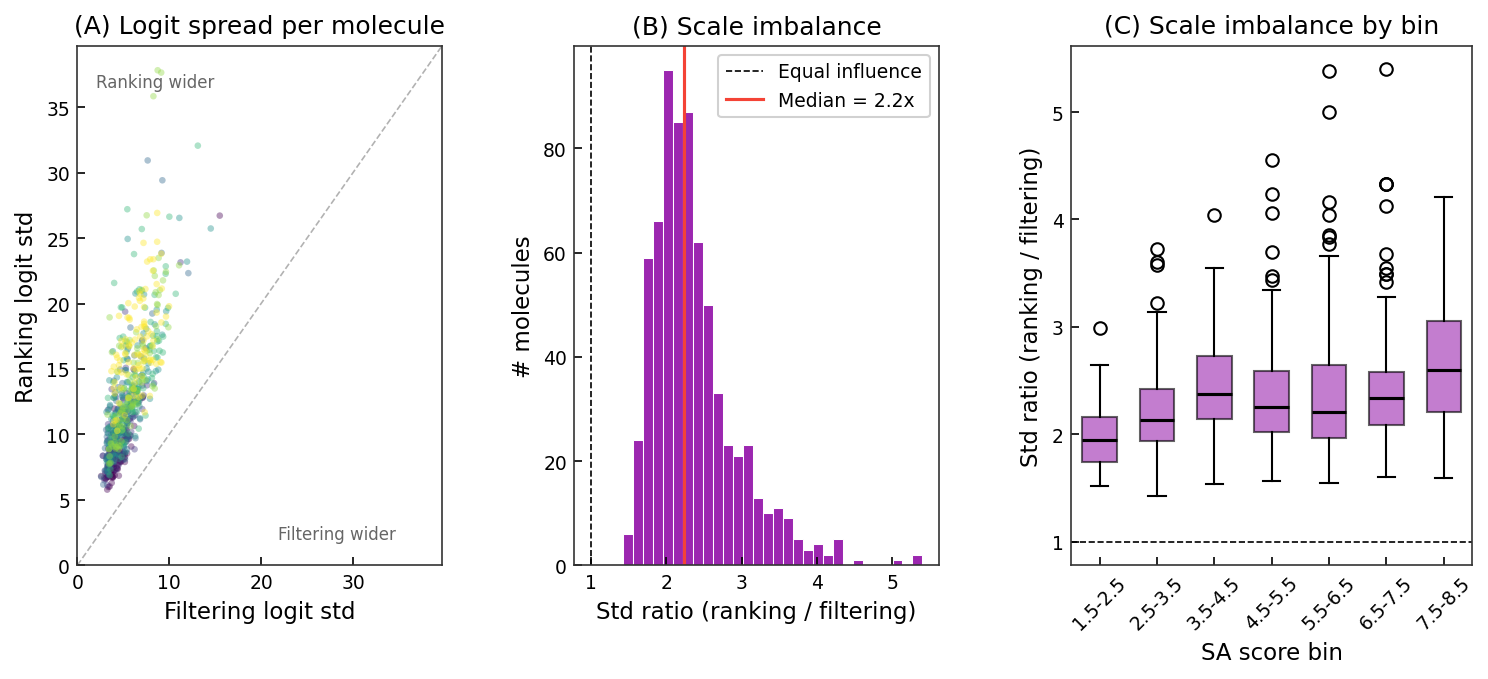


Std ratio (ranking / filtering):
  mean = 2.37x,  median = 2.24x
  min  = 1.42x,  max    = 5.40x


In [20]:
fig = plt.figure(figsize=(12, 4.5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.35)

# (A) Scatter: filtering std vs ranking std
ax = fig.add_subplot(gs[0])
ax.scatter(df["filt_std"], df["rank_std"], s=10, alpha=0.4,
           c=df["bin"].astype("category").cat.codes, cmap="viridis", edgecolors="none")
lim = max(df["filt_std"].max(), df["rank_std"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.3, linewidth=0.8)
ax.set_xlabel("Filtering logit std")
ax.set_ylabel("Ranking logit std")
ax.set_title("(A) Logit spread per molecule")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.text(0.05, 0.92, "Ranking wider", transform=ax.transAxes, fontsize=8, color="#666")
ax.text(0.55, 0.05, "Filtering wider", transform=ax.transAxes, fontsize=8, color="#666")

# (B) Histogram of std ratio
ax = fig.add_subplot(gs[1])
finite_ratios = df["std_ratio"][np.isfinite(df["std_ratio"])]
ax.hist(finite_ratios, bins=30, color=COLORS["combined"], edgecolor="white", linewidth=0.5)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8, label="Equal influence")
ax.axvline(finite_ratios.median(), color=COLORS["ranking"], linestyle="-",
           linewidth=1.5, label=f"Median = {finite_ratios.median():.1f}x")
ax.set_xlabel("Std ratio (ranking / filtering)")
ax.set_ylabel("# molecules")
ax.set_title("(B) Scale imbalance")
ax.legend(framealpha=0.9)

# (C) Box plot by SA-score bin
ax = fig.add_subplot(gs[2])
data_by_bin = [df.loc[df["bin"] == b, "std_ratio"].values for b in bins]
bp = ax.boxplot(data_by_bin, labels=[b.replace("_", "-") for b in bins],
                patch_artist=True, widths=0.6,
                medianprops={"color": "black", "linewidth": 1.5})
for patch in bp["boxes"]:
    patch.set_facecolor(COLORS["combined"])
    patch.set_alpha(0.6)
ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("SA score bin")
ax.set_ylabel("Std ratio (ranking / filtering)")
ax.set_title("(C) Scale imbalance by bin")
ax.tick_params(axis="x", labelrotation=45)

plt.savefig("fig_logit_scale_comparison.pdf", bbox_inches="tight")
plt.savefig("fig_logit_scale_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nStd ratio (ranking / filtering):")
print(f"  mean = {finite_ratios.mean():.2f}x,  median = {finite_ratios.median():.2f}x")
print(f"  min  = {finite_ratios.min():.2f}x,  max    = {finite_ratios.max():.2f}x")